### Back-emf of 2D PMSM 
- 6 slots wih 3 phase currents
- 1 pole

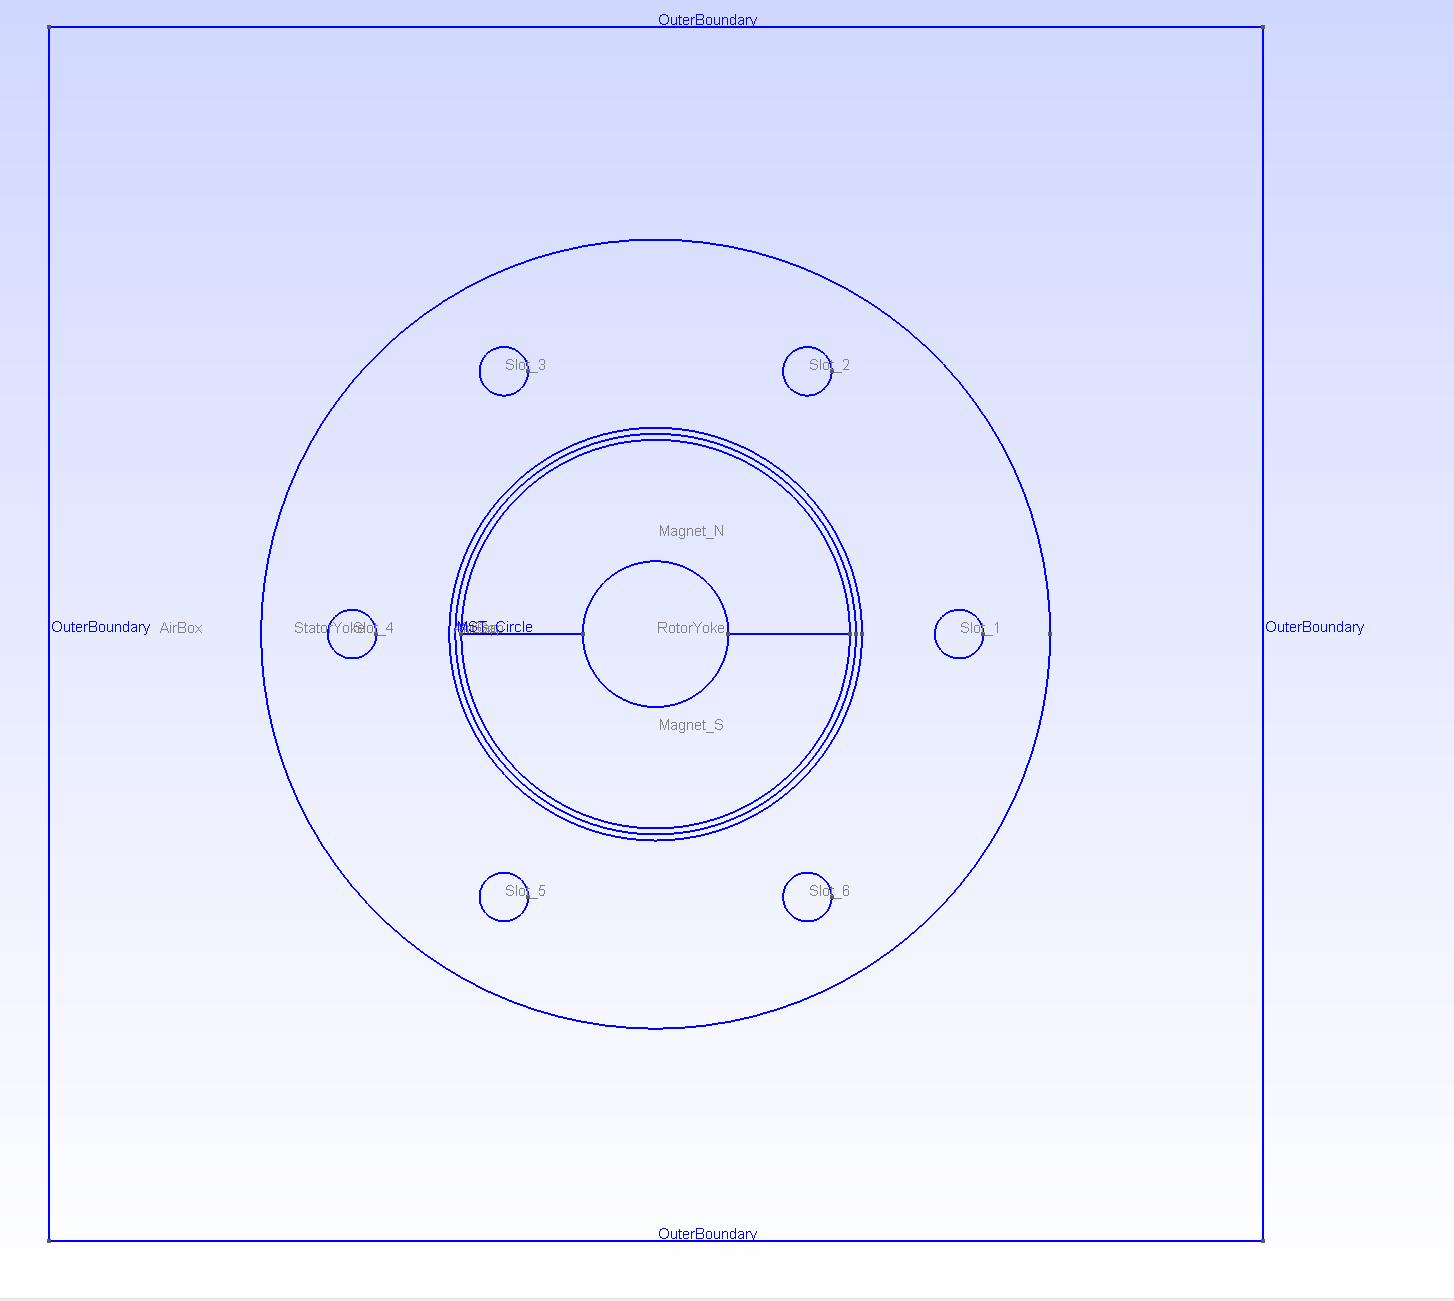

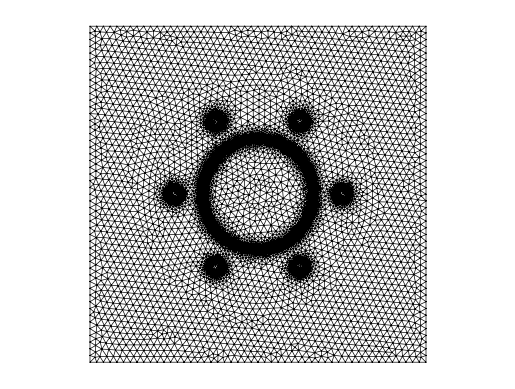

In [1]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio

# Add repository root to Python path. Helps to find files and modules
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))


m = meshio.read("mesh/mesh_pmsm_2d.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

import matplotlib.tri as mtri

draw(mesh)
plt.axis("equal")
plt.show()



Define basis for each region

In [2]:
from skfem import Basis, ElementTriP2

e = ElementTriP2()
basis = Basis(mesh, e, intorder=4)

basis_rotor_yoke = basis.with_elements(mesh.subdomains["RotorYoke"])
basis_stator_yoke = basis.with_elements(mesh.subdomains["StatorYoke"])
basis_air_box = basis.with_elements(mesh.subdomains["AirBox"])
basis_air_gap = basis.with_elements(mesh.subdomains["AirGap"])

basis_magnet = basis.with_elements(mesh.subdomains["Magnet"])

# Slot to phzse current mapping
"""
Slot_1 → A+
Slot_2 → B−
Slot_3 → C+
Slot_4 → A−
Slot_5 → B+
Slot_6 → C−
"""

slot_bases = [
    basis.with_elements(mesh.subdomains[f"Slot_{i}"])
    for i in range(1, 7)
]

# For example Slot_1 → A+
print(slot_bases[0])

# Evaluate slot area for to solve the current denisty
# Test winding area
from skfem import Functional
@Functional
def area(w):
    return 1.0

print()
slot_area = area.assemble(slot_bases[0])
#slot_area = 5.0265e-5  # m^2, from Comsol
print("In units of m: ", slot_area)

<skfem CellBasis(MeshTri1, ElementTriP2) object>
  Number of elements: 248
  Number of DOFs: 38737
  Size: 214272 B

In units of m:  5.007820143519473e-05


# Open-Circuit Back-EMF Calculation

For the open-circuit back-EMF calculation, the stator currents are set to zero,

$$
I_A = I_B = I_C = 0.
$$

The rotor is rotated at a prescribed mechanical angular velocity

$$
\omega_m = \frac{d\theta_m}{dt}.
$$

The magnetic field is solved for a sequence of rotor positions
$\theta_m$.

---

## Magnetostatic FEM Problem

At each rotor position, the magnetic vector potential is obtained from

$$
\boxed{
\mathbf{K}(\theta_m)\mathbf{A}(\theta_m)
=
\mathbf{f}_{\mathrm{PM}}(\theta_m)
}
$$

where

- $\mathbf{A}$ is the discretized magnetic vector potential,
- $\mathbf{K}$ is the magnetic stiffness matrix,
- $\mathbf{f}_{\mathrm{PM}}$ represents the permanent-magnet excitation.

---

## Rotor Position Sweep

The magnetic problem is solved for a sequence of rotor positions. Therefore, the magnetic vector potential becomes a function of rotor position,

$$
A_z=A_z(x,y,\theta_m).
$$

---

## Flux Linkage

The magnetic flux through a surface $S$ is

$$
\boxed{
\Phi
=
\int_S
\mathbf{B}\cdot\mathbf{n}\,dS
}
$$

where $\mathbf{n}$ is the surface normal.

For a winding with $N$ turns, the flux linkage is

$$
\boxed{
\lambda=N\Phi.
}
$$

For a simple 2D concentrated winding, the flux linkage can alternatively be obtained from the magnetic vector potential on the positive and negative coil sides. This comes from the Stoke's theorem,

$$
\boxed{
\lambda_A(\theta_m)
=
NL
\left(
\overline{A}_{z,A^+}
-
\overline{A}_{z,A^-}
\right)
}
$$

where

- $N$ is the number of turns,
- $L$ is the motor axial length,
- $\overline{A}_{z,A^+}$ is the average $A_z$ on the positive side of phase A,
- $\overline{A}_{z,A^-}$ is the average $A_z$ on the negative side of phase A.

Similarly,

$$
\lambda_B(\theta_m)
=
NL
\left(
\overline{A}_{z,B^+}
-
\overline{A}_{z,B^-}
\right),
$$

and

$$
\lambda_C(\theta_m)
=
NL
\left(
\overline{A}_{z,C^+}
-
\overline{A}_{z,C^-}
\right).
$$

---

## Back-EMF

According to Faraday's law, the induced voltage is

$$
\boxed{
e_A(t)
=
-\frac{d\lambda_A}{dt}.
}
$$

Since

$$
\theta_m=\theta_m(t),
$$

the chain rule gives

$$
\frac{d\lambda_A}{dt}
=
\frac{d\lambda_A}{d\theta_m}
\frac{d\theta_m}{dt}.
$$

Therefore,

$$
\boxed{
e_A(\theta_m)
=
-\omega_m
\frac{d\lambda_A}{d\theta_m}.
}
$$

Similarly,

$$
\boxed{
e_B(\theta_m)
=
-\omega_m
\frac{d\lambda_B}{d\theta_m}
}
$$

and

$$
\boxed{
e_C(\theta_m)
=
-\omega_m
\frac{d\lambda_C}{d\theta_m}.
}
$$

---

## Numerical Differentiation

After solving the magnetic problem for a sequence of rotor positions, the flux linkage is available as

$$
\lambda_A(\theta_{m,i}).
$$

The derivative can be approximated numerically,

$$
\frac{d\lambda_A}{d\theta_m}
\approx
\frac{
\lambda_A(\theta_{m,i+1})
-
\lambda_A(\theta_{m,i-1})
}{
\theta_{m,i+1}
-
\theta_{m,i-1}
}.
$$

Therefore,

$$
\boxed{
e_A(\theta_{m,i})
\approx
-\omega_m
\frac{
\lambda_A(\theta_{m,i+1})
-
\lambda_A(\theta_{m,i-1})
}{
\theta_{m,i+1}
-
\theta_{m,i-1}
}.
}
$$



In [3]:
mu0 = 4 * np.pi * 1e-7
mu_air = mu0
mu_pm = mu0
mu_iron = 1000 * mu0
# w.mu little confusing but it just wraps the permeability to some variable w
@BilinearForm
def laplace(A, v, w):
    return 1/w.mu*dot(grad(A), grad(v))

I_0 = 0
f = 50 # Frequency of the current
omega = 2*np.pi*f
t = 0  # start time
Nturns = 100

Br = 0.8 # Remanence 
remanence_angle = np.pi # Angle of the remanence in the magnet. 0 means that the magnetization is along the  negativex-axis
torques_arkkio = []
torques_mst = []

number_of_steps = 100
mechanical_angle_step = 2 * np.pi / number_of_steps

mechanical_angles = np.linspace(
    0,
    2 * np.pi,
    number_of_steps,
    endpoint=False  # 2pi not indluded, because 0 and 2pi are the same position
)

Az_all = []

A_phase = 0
B_phase = 2*np.pi/3
C_phase = 4*np.pi/3
phase_shift = 0

iteration = 1
for mech_angle_radian in mechanical_angles:

    I_A = I_0*np.cos(mech_angle_radian + A_phase + phase_shift)
    I_B = I_0*np.cos(mech_angle_radian + B_phase + phase_shift)
    I_C = I_0*np.cos(mech_angle_radian + C_phase + phase_shift)

    J_A = Nturns * I_A / slot_area
    J_B = Nturns * I_B / slot_area
    J_C = Nturns * I_C / slot_area
    @LinearForm
    def slot_rhs(v, w):
        return w.J * v


    @LinearForm
    def magnet_rhs(v, w):
        Brx = w.Brx
        Bry = w.Bry
        mu = w.mu  

        return 1/mu * (
            Brx * v.grad[1]
            -
            Bry * v.grad[0]
        )

    # Assemble left hand side. We have linear materials, so just change permeability

    # RotorYoke and StatorYoke are modelled as magnetic iron
    S_mat = laplace.assemble(basis_rotor_yoke, mu=mu_iron)
    S_mat += laplace.assemble(basis_stator_yoke, mu=mu_iron)

    # Other parts are modelled as non magnetic
    S_mat += laplace.assemble(basis_air_box, mu=mu_air)
    S_mat += laplace.assemble(basis_air_gap, mu=mu_air)
    S_mat += laplace.assemble(basis_magnet, mu=mu_air)
    

    # Slots (non magnetic air with current density source) are modelled as non magnetic
    for basis_i in slot_bases:
        S_mat += laplace.assemble(basis_i, mu=mu_air)

    # Assemble right hand side for slots. Add current density source to each slot. We use 3phase currents
    b =  slot_rhs.assemble(slot_bases[0], J = +J_A)
    b +=  slot_rhs.assemble(slot_bases[1], J = -J_B)
    b +=  slot_rhs.assemble(slot_bases[2], J = +J_C)
    b +=  slot_rhs.assemble(slot_bases[3], J = -J_A)
    b +=  slot_rhs.assemble(slot_bases[4], J = +J_B)
    b +=  slot_rhs.assemble(slot_bases[5], J = -J_C)

    # Assemble right hand side for magnets. These are the remanence source, they behave as current sources in weak form.

    # MAGNET 
    Brx = Br * np.cos(mech_angle_radian + remanence_angle)  
    Bry = Br * np.sin(mech_angle_radian + remanence_angle)

    # Keep the direction of magnetization positive for north poles
    b += magnet_rhs.assemble(
        basis_magnet,
        Brx= Brx,
        Bry= Bry,
        mu=mu_pm,
    )


    S_mat, b = enforce(S_mat, b, D=mesh.boundary_nodes())

    A_z = solve(S_mat, b)
    Az_all.append(A_z.copy())

    theta_elec = omega * t + phase_shift
    print("Difference of angles in rotor magnet and stator field, should be constant:", mech_angle_radian - theta_elec)
    print(f"{iteration/number_of_steps*100:.1f}% done")
    # omega = d(mechanical_angle)/dt   ->  dt = d(mechanical_angle)/omega
    # So the amount we have to update time is the mechanical angle step divided by the angular speed of the rotor
    dt = mechanical_angle_step / omega
    t = t + dt
    iteration += 1




Difference of angles in rotor magnet and stator field, should be constant: 0.0
1.0% done
Difference of angles in rotor magnet and stator field, should be constant: 0.0
2.0% done
Difference of angles in rotor magnet and stator field, should be constant: 0.0
3.0% done
Difference of angles in rotor magnet and stator field, should be constant: 0.0
4.0% done
Difference of angles in rotor magnet and stator field, should be constant: 0.0
5.0% done
Difference of angles in rotor magnet and stator field, should be constant: 0.0
6.0% done
Difference of angles in rotor magnet and stator field, should be constant: 0.0
7.0% done
Difference of angles in rotor magnet and stator field, should be constant: 0.0
8.0% done
Difference of angles in rotor magnet and stator field, should be constant: -1.1102230246251565e-16
9.0% done
Difference of angles in rotor magnet and stator field, should be constant: -1.1102230246251565e-16
10.0% done
Difference of angles in rotor magnet and stator field, should be cons

## Post-processing
Compute back-emf based on our equations